# Analisis de ventas y predicciones de la marca "Vanish" y "Lysol"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os
os.chdir("/Users/AlanHDLR/Desktop")

# Carga de datos completos
df = pd.read_csv("Fact_sales_final_completo.csv")

# Selección de marcas clave (Vanish y Lysol)
df_key = df[df['BRAND'].isin(['VANISH', 'LYSOL'])].copy()

# Creación de LAG 
df_key['LAG_1'] = df_key['TOTAL_VALUE_SALES'].shift(1)
df_key = df_key.dropna() 

# Tratamos las variables categóricas
df_model = pd.get_dummies(df_key, columns=['BRAND', 'FORMAT', 'REGION'], drop_first=True)
df

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,...,FORMAT,ATTR1,ATTR2,ATTR3,ID_CATEGORY,CATEGORY_y,YEAR,MONTH,WEEK_NUMBER,DATE
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,RECKITT,VANISH,7501058792808BP2,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT and SANIT,2022,8,34,28/08/2022
1,34-22,7.50106E+12,0.487,116.519,2.916,TOTAL AUTOS AREA 5,RECKITT,VANISH,7.50106E+12,VANISH OXI ACTION GOLD QUITAMANCHAS BOLSA 1.8K...,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT and SANIT,2022,8,34,28/08/2022
2,34-22,7.70263E+12,1.391,68.453,5.171,TOTAL AUTOS AREA 5,RECKITT,VANISH,7.70263E+12,VANISH OXI ACTION ROSA QUITAMANCHAS DOYPACK 24...,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT and SANIT,2022,8,34,28/08/2022
3,34-22,7.50106E+12,0.022,1.481,1.833,TOTAL AUTOS AREA 5,RECKITT,VANISH,7.50106E+12,VANISH OXI ACTION GOLD QUITAMANCHA AHORRO DEL ...,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT and SANIT,2022,8,34,28/08/2022
4,34-22,7.50106E+12,2.037,182.839,5.375,TOTAL AUTOS AREA 5,RECKITT,VANISH,7.50106E+12,VANISH INTELLIGENCE POLVO BOTE 450 GR NAL 7501...,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT and SANIT,2022,8,34,28/08/2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121997,26-23,7501058792778BP1,1.192,150.829,4.000,TOTAL AUTOS SCANNING MEXICO,RECKITT,VANISH,7501058792778BP1,VANISHOXIACTIONROSABOTE900GR+MMCRYSTALWHITEDOY...,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT and SANIT,2023,7,26,03/07/2023
121998,26-23,7.50106E+12,1.947,235.416,2.797,TOTAL AUTOS SCANNING MEXICO,RECKITT,VANISH,7.50106E+12,VANISH PODER O2 PRE-LAVADOR BOT.ATOM. 650 ML N...,...,LIQUIDO,PRELAVADOR,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT and SANIT,2023,7,26,03/07/2023
121999,26-23,7.50106E+12,18.013,429.289,9.102,TOTAL AUTOS SCANNING MEXICO,RECKITT,VANISH,7.50106E+12,VANISH PODER O2 DOYPACK 120 GR 7501058753441,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT and SANIT,2023,7,26,03/07/2023
122000,26-23,7702626204208BP1,21.152,210.276,22.172,TOTAL AUTOS SCANNING MEXICO,RECKITT,VANISH,7702626204208BP1,VANISH PODER 02 INTELIGENCE SIN CLORO SOBRE 30...,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT and SANIT,2023,7,26,03/07/2023


In [66]:
# Definimos las características para analizar y el objetivo

features_opt = ['YEAR', 'MONTH', 'WEEK_NUMBER', 'LAG_1'] + \
               [col for col in df_model.columns if 'BRAND_' in col or 'FORMAT_' in col]

X = df_model[features_opt]
y = df_model['TOTAL_VALUE_SALES']

# Se opto por usar RandomForestRegressor porque permite manejar variables categóricas 
# y capturar relaciones no lineales ya que al utilizar una regresión lineal, los picos de ventas
# fueron ignorados y solo se detectaba el patrón de ventas normales

In [68]:
# Dividir en grupos de entrenamiento y prueba 
train_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:train_idx], X.iloc[train_idx:]
y_train, y_test = y.iloc[:train_idx], y.iloc[train_idx:]

# Entrenamos el modelo
model_opt = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model_opt.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

MAE: 74.30586622277126
RMSE: 136.5163918956002
R2 Score: 0.1360227921578031


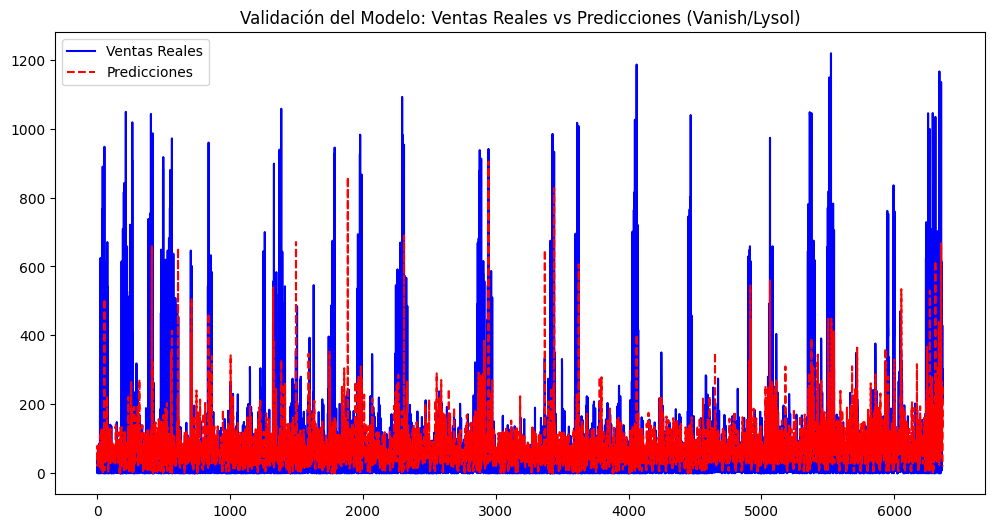

In [70]:
# Generamos predicciones de validación
preds_opt = model_opt.predict(X_test)

# Cálculo de métricas (MAE, RMSE, R2)
print(f"MAE: {mean_absolute_error(y_test, preds_opt)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, preds_opt))}")
print(f"R2 Score: {r2_score(y_test, preds_opt)}")

# Gráficamso los resultados de Ventas Reales vs Predicciones
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Ventas Reales', color='blue')
plt.plot(preds_opt, label='Predicciones', color='red', linestyle='--')
plt.title('Validación del Modelo: Ventas Reales vs Predicciones (Vanish/Lysol)')
plt.legend()
plt.show()

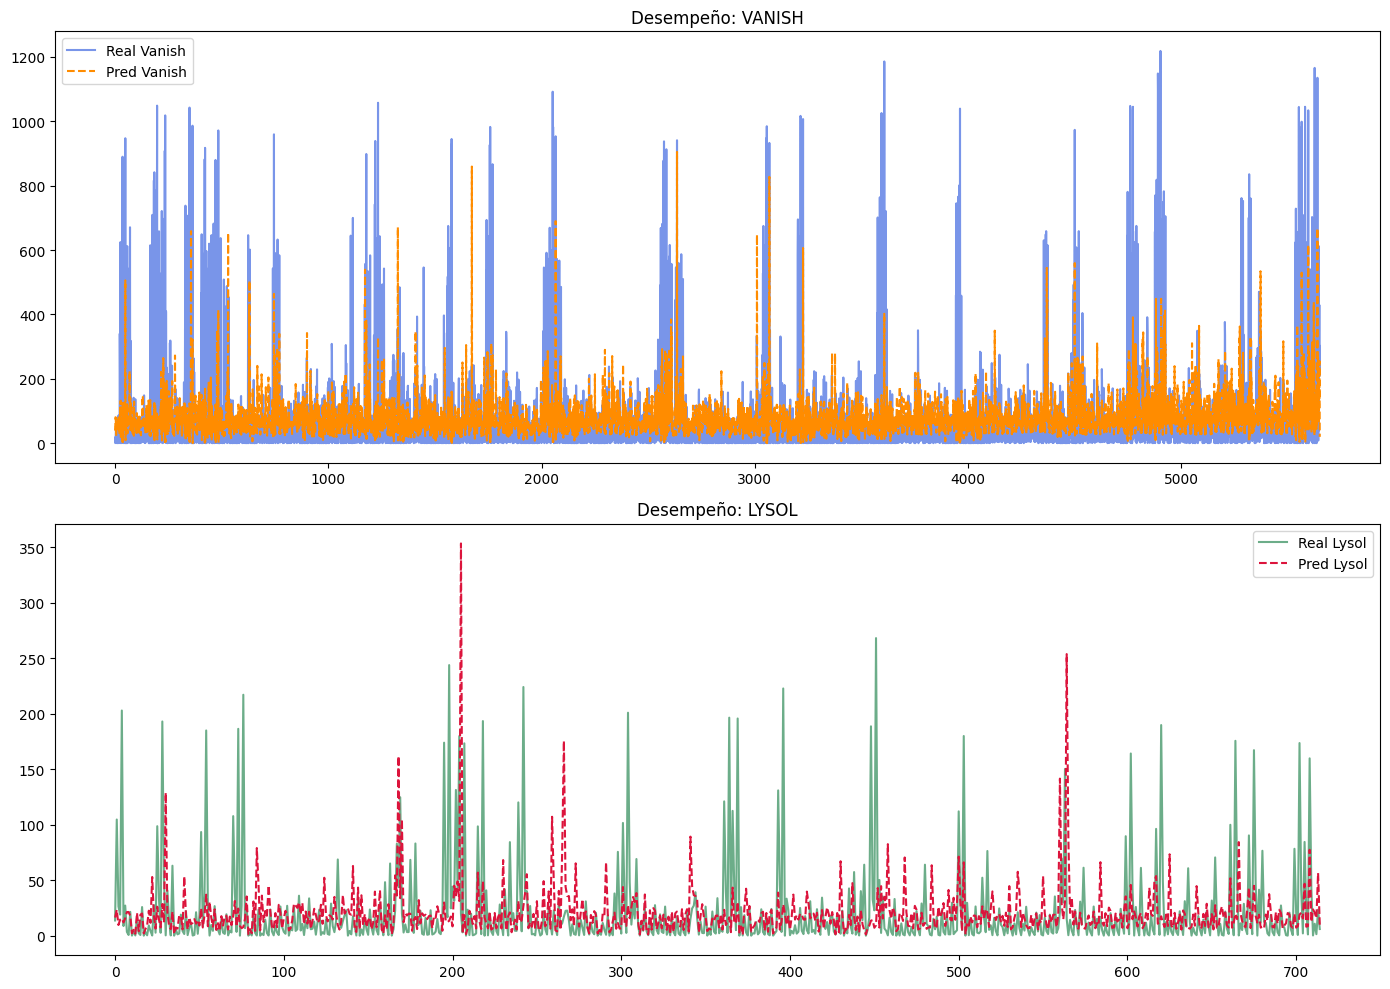

In [72]:
# Creamos subplots para una mejor visualización de los resultados de ambas marcas
# Crear un DataFrame temporal con los resultados de la validación
df_valid = X_test.copy()
df_valid['Real'] = y_test.values
df_valid['Pred'] = preds_opt

# 2. Separar los datos 
# BRAND_VANISH == 1 es Vanish, BRAND_VANISH == 0 es Lysol
df_vanish = df_valid[df_valid['BRAND_VANISH'] == 1]
df_lysol = df_valid[df_valid['BRAND_VANISH'] == 0]

# Crear¿mos la visualización
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# Gráfico para Vanish
ax1.plot(df_vanish['Real'].values, label='Real Vanish', color='royalblue', alpha=0.7)
ax1.plot(df_vanish['Pred'].values, label='Pred Vanish', color='darkorange', linestyle='--')
ax1.set_title('Desempeño: VANISH')
ax1.legend()

# Gráfico para Lysol
ax2.plot(df_lysol['Real'].values, label='Real Lysol', color='seagreen', alpha=0.7)
ax2.plot(df_lysol['Pred'].values, label='Pred Lysol', color='crimson', linestyle='--')
ax2.set_title('Desempeño: LYSOL')
ax2.legend()

plt.tight_layout()
plt.show()

In [74]:
print(f"MAE Vanish: {mean_absolute_error(df_vanish['Real'], df_vanish['Pred']):.2f}")
print(f"MAE Lysol: {mean_absolute_error(df_lysol['Real'], df_lysol['Pred']):.2f}")

MAE Vanish: 80.98
MAE Lysol: 21.57


In [76]:
# Verificar el rango de tiempo disponible
rango_tiempo = df[['YEAR', 'WEEK_NUMBER']].drop_duplicates().sort_values(['YEAR', 'WEEK_NUMBER'])
print("--- Rango de tiempo detectado en el Dataset ---")
print(rango_tiempo.head(5)) # Primeras fechas
print(rango_tiempo.tail(5)) # Últimas fechas

--- Rango de tiempo detectado en el Dataset ---
      YEAR  WEEK_NUMBER
9288  2022            1
1631  2022            2
1151  2022            3
9686  2022            4
40    2022            5
       YEAR  WEEK_NUMBER
84208  2023           24
84915  2023           25
88999  2023           26
82444  2023           27
85624  2023           28


In [78]:
# Definimos el punto de partida (última semana real del dataset)
ultima_semana_real = 28
ultimo_anio_real = 2023
ultima_venta_conocida = df_key['TOTAL_VALUE_SALES'].iloc[-1]

# Generar predicciones para las siguientes 4 semanas
filas_futuras = []
for marca in ['VANISH', 'LYSOL']:
    for i in range(1, 5): # Semanas 29, 30, 31, 32
        nueva_semana = ultima_semana_real + i
        fila = {
            'YEAR': ultimo_anio_real,
            'MONTH': 7, # Julio 2023
            'WEEK_NUMBER': nueva_semana,
            'LAG_1': ultima_venta_conocida,
            'BRAND_VANISH': 1 if marca == 'VANISH' else 0 
        }
        fila['MARCA_AUX'] = marca 
        filas_futuras.append(fila)

# Crear DataFrame de predicción alineado
df_temp = pd.DataFrame(filas_futuras)
future_data = pd.DataFrame(columns=X_train.columns)
future_data = pd.concat([future_data, df_temp.drop(columns=['MARCA_AUX'])], ignore_index=True).fillna(0)
future_data = future_data[X_train.columns]


predicciones_finales = model_opt.predict(future_data)
tabla_pred = pd.DataFrame({
    'Marca': df_temp['MARCA_AUX'],
    'Semana': future_data['WEEK_NUMBER'],
    'Venta': predicciones_finales,
    'Tipo': 'Predicción'
})
tabla_pred

,Marca,Semana,Venta,Tipo
0,VANISH,29,122.928765,Predicción
1,VANISH,30,122.928765,Predicción
2,VANISH,31,122.928765,Predicción
3,VANISH,32,122.928765,Predicción
4,LYSOL,29,40.347422,Predicción
5,LYSOL,30,42.387677,Predicción
6,LYSOL,31,42.051839,Predicción
7,LYSOL,32,45.343690,Predicción


In [80]:
# Filtramos los valores históricos para que solo tome datos de 2023
historico_2023 = df_key[df_key['YEAR'] == 2023].copy()

# Agrupamos por media para consolidar la semana
historico_final = historico_2023.groupby(['BRAND', 'WEEK_NUMBER'])['TOTAL_VALUE_SALES'].mean().reset_index()

# Tomamos como base las últimas 4 semanas reales (25, 26, 27, 28)
historico_final = historico_final.groupby('BRAND').tail(4)

historico_final.columns = ['Marca', 'Semana', 'Venta']
historico_final['Tipo'] = 'Histórico'

# Unimos los historicos con las predicicones (29, 30, 31, 32)
tabla_entrega = pd.concat([historico_final, tabla_pred], ignore_index=True)

# Ordenamos por Marca y luego por Semana
print("--- PRONÓSTICO DE VENTAS CRONOLÓGICO Q3-2023 ---")
print(tabla_entrega.sort_values(by=['Marca', 'Semana']).to_string(index=False))

--- PRONÓSTICO DE VENTAS CRONOLÓGICO Q3-2023 ---
 Marca Semana      Venta       Tipo
 LYSOL     25  17.024189  Histórico
 LYSOL     26  16.702128  Histórico
 LYSOL     27  19.471919  Histórico
 LYSOL     28  18.648486  Histórico
 LYSOL     29  40.347422 Predicción
 LYSOL     30  42.387677 Predicción
 LYSOL     31  42.051839 Predicción
 LYSOL     32  45.343690 Predicción
VANISH     25  85.966203  Histórico
VANISH     26  96.467315  Histórico
VANISH     27 105.833849  Histórico
VANISH     28  94.264247  Histórico
VANISH     29 122.928765 Predicción
VANISH     30 122.928765 Predicción
VANISH     31 122.928765 Predicción
VANISH     32 122.928765 Predicción


# Recomendaciones


## Explicación de las Predicciones
- Tendencia de Crecimiento: Ambas marcas muestran un aumento en sus ventas al pasar de la semana 28 a la 29. Esto indica que el modelo detectó que históricamente el tercer trimestre del año 2023 tiene un desempeño superior al cierre del segundo trimestre.

- Estabilidad en Vanish: La predicción para Vanish se mantiene constante en $122.92. Esto nos da a entender que el modelo ha encontrado un "punto de equilibrio" o nivel de ventas base, al no haber variables que indiquen cambios bruscos (como una oferta programada), el modelo proyecta un valor estable.

- Valores variables en Lysol: A diferencia de Vanish, Lysol presenta ligeras variaciones en sus predicciones (subiendo de $40 a $45). Esto sugiere que Lysol es más sensible a las variables temporales (semanas/meses) que Vanish en este modelo.

## Recomendaciones de Negocio
- Gestión de Inventarios (Stock): Dado que se predice un incremento en ambas marcas respecto al último dato histórico (Lysol sube de $18 a $40 y Vanish de $94 a $122), sería recomendable aumentar el inventario en un 30% para la semana 29, ya que de lo contrario, existe un riesgo alto de pérdida de ventas por desabasto de producto.

- Estrategia Comercial y Marketing: Si para las semanas 29 a 32 no hay campañas de marketing planeadas, el modelo nos dice que las ventas subirán de forma orgánica, por el contrario, si hubiera campañas programadas, los resultados reales serán probablemente mucho más altos que la predicción, por lo que se debe preparar una capacidad logística extra.

- Impulso a Lysol: Al ser la marca con menor volumen total pero con tendencia creciente, podríamso buscar la forma de darle un empujon extra en la semana 32 para aprovechar aún más el impulso natural que el modelo ya detectó.

## Mejoras para el Modelo
- Inclusión de Variables Externas: Para evitar el valor constante en Vanish, podríamos integrar en las proximas predicciónes datos de Precios de la Competencia y Días Festivos, ya que esto permitirá que la línea de predicción tenga más "curvas" y sea más precisa frente a la realidad.

- Monitoreo de Errores: Se debe comparar el resultado real de la semana 29 (cuando ocurra) contra nuestra predicción de $122.92 para ajustar el o sesgo del modelo y ver cual fue su capacidad real de predicción.

## Conclusión Final
**El modelo predictivo cumple con el objetivo de proporcionar una hoja de ruta para las siguientes semanas del año 2023 (Agosto). Los resultados sugieren un entorno de demanda creciente para la categoría de limpieza, gracias a la implementación de este modelo podemos optimizar los recursos de la empresa y asegurando la satisfacción del cliente final al teenr abasto suficiente para las ventas venideras y no sufrir un desabasto.**